GridProblem self-check passed.


,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,4,4,6,2,7
1,DFS,success,NaN,4,4,6,2,7
2,DLS,success,10.0,4,4,6,5,0
3,IDS,success,4.0,4,4,15,5,0


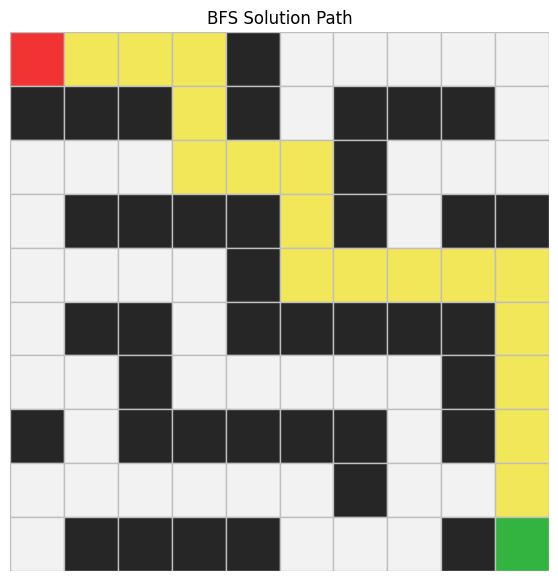

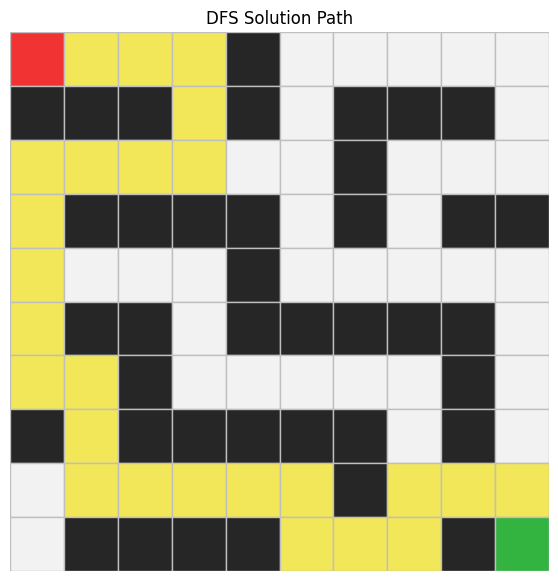

In [1]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


# Helper Functions

def reconstruct_path(node: Node) -> List[Any]:
  path = []

  while node is not None:
    path.append(node.state)
    node = node.parent

  path.reverse()
  return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions

def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])



MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        legal_actions = []

        for action, (dr, dw) in MOVES.items():
            row, col = state
            neighbour_cell = (row + dr, col + dw)
            if self.in_bounds(neighbour_cell) and self.is_free(neighbour_cell):
                legal_actions.append(action)
        return legal_actions

        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
      return 1

      raise NotImplementedError("Complete GridProblem.action_cost")


test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")





# Simple Drone Map
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)



def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    #Visualise a grid and, optionally, a solution path

    arr = np.array(grid)

    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )
                plt.show()
                plot_path(sample_grid, start, goal, title="Sample Drone Map")


class SearchAlgorithm(ABC):
###Base class for search algorithms.

  def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
    s = node.state
    for action in problem.actions(s):
      s_prime = problem.result(s, action)
      cost = node.path_cost + problem.action_cost(s, action, s_prime)
      yield Node(state=s_prime, parent=node, action= action, path_cost=cost)


  @abstractmethod
  def search(self, problem: Problem) -> SearchResult:
       pass




# Breadth-First Search (BFS)
class BreadthFirstSearch(SearchAlgorithm):
  def search(self, problem: Problem) -> SearchResult:
      algorithm = "BFS"
      nodes_expanded = 0
      max_frontier_size = 0

      node = Node(state=problem.initial_state())

      if problem.is_goal(node.state):
        return SearchResult(algorithm, "success", node, nodes_expanded,max_frontier_size)

      frontier = deque([node])
      reached = {node.state}

      while frontier:
        node = frontier.popleft()

        nodes_expanded += 1

        for child in self.expand(problem, node ):
          s = child.state

          if problem.is_goal(s):
            return SearchResult(algorithm,"success", child, nodes_expanded, max_frontier_size, len(reached))

          if s not in reached:
            reached.add(s)
            frontier.append(child)

        max_frontier_size = max(max_frontier_size, len(frontier))
      return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached))



class DepthFirstSearch(SearchAlgorithm):
  def search(self, problem: Problem) -> SearchAlgorithm:
    algorithm = "DFS"
    nodes_expanded = 0
    max_frontier_size = 1

    node = Node (state=problem.initial_state())

    if problem.is_goal(node.state):
      return SearchResult(algorithm, "success", node, nodes_expanded, max_frontier_size)

    frontier = [node]
    reached = {node.state}


    while frontier:
      node = frontier.pop()

      nodes_expanded += 1

      children = self.expand(problem, node)
      children = reversed(list(children))

      for child in children:
        s = child.state

        if problem.is_goal(s):
            return SearchResult(algorithm, "success", child, nodes_expanded, max_frontier_size, len(reached))
        if s not in reached:
            reached.add(s)
            frontier.append(child)

      max_frontier_size = max(max_frontier_size, len(frontier))


    return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached))




class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:


      if problem.is_goal(node.state) :
        return (node, "success")

      elif node.depth >= limit :
        return (None, "cutoff")

      else:
        metrics["nodes_expanded"] += 1
        cutoff_occurred = False

        for child in self.expand(problem, node):
          if state_is_on_path(node, child.state):
            continue

          metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)

          result, status = self._recursive_dls(
                problem=problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1,
            )

          if status == "success":
            return (result, "success")

          elif status == "cutoff":
              cutoff_occurred = True


        if cutoff_occurred:
            return (None, "cutoff")
        else:
            return (None, "failure")




class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        total_nodes_expanded = 0
        max_stack_size = 0
        iteration_log = []

        dls = DepthLimitedSearch()

        for limit in range(max_depth + 1):
          result = dls.search(problem, limit = limit )

          total_nodes_expanded += result.nodes_expanded
          max_stack_size = max(max_stack_size, result.max_frontier_size)

          iteration_log.append({"limit": limit,"status" : result.status, "nodes_expanded": result.nodes_expanded})

          if result.status == "success":
            return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    limit=limit,
                    iterations=iteration_log,
                )

          elif result.status == "failure":
              return SearchResult(algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    limit=limit,
                    iterations=iteration_log,

              )
              return SearchResult(
                  algorithm=algorithm,
                  status="cutoff",
                  solution=None,
                  nodes_expanded=total_nodes_expanded,
                  max_frontier_size=max_stack_size,
                  limit=max_depth,
                  iterations=iteration_log,

              )



bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)



bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)



custom_grid_1 = [
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 1, 1, 0, 0, 1, 1],
    [1, 1, 1, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
]
custom_start_1 = (0,0)
custom_goal_1 = (10,10)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)

custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=10),
    ids.search(custom_problem_1, max_depth=30),
]

show_results(custom_results_1)





custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 0, 0, 0, 0],
    [0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (2, 2)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=10),
    ids.search(custom_problem_2, max_depth=20),
]

show_results(custom_results_2)












































Question 15.1
1. State is the  row- column tuple that represents the egents current position.
2. Action is the direction the agent moves, like (-1, 0)which is up, (1,0) which is down.

3.  Result takes state and an action and returns the new state.

4.Separating the problem definition from the search algorithm is useful because it makes the system more flexible, reusable, and easier to maintain.This can make it posible to reuse it for many other algortims.




Question 15.2
1. The BFS uses, FIFI to ensure that nodes that are discovered earlier are expanded before nodes discovered later., ensurng level by level exploration.

2.This is beacuse it explores all nodes at the curret depth before moviing on to the nodes at the next depth level.

3. The reached nodes keeeps track of all nodes explored by the agent, and ensures the agent doesnt revisit thoses nodes. This prevents the agent form getting trapped repeating the same paths


Quesiion 15.3
1. The use a stck beacuse it wants to always explore the most recently discovered node.

2. No. DFS's goal is to go as deep as possible along one branch before exploring others. Because of this, it may find a path to the goal quickly, but that path might be much longer than the shortest one

3. DFS typically uses less memory when the search tree is wide. The DFS only needs to store the current path from the root to the current node, plus a few unexplored nodes. The BFS must stoe all nodes at the current fonrtier level

4. DFS performs badly when the goal is close to the start but the it explores a deep branch first, it may waste alot of time.

15.4

1. When the depth_limit is to small, and the goal sate is deeper than the limit. If the seach reaches the limit it stopes and returns a special result called cutoff rather than failure.

2. Cutofff means the search was stopped because it hit the depth limit, so we don't know whether a solution exists deeper down.

3. DFS explores as deep as possible but DLS only explores up to a fixed depth.The DFS has no restrictions but the DLS has a depth limit. The DFS may nver terminate in an infnite space but the DLS always terminates.

4. Path-cycle checking prevents the search from revisiting a node that is already on the current path.

15.5
1. Because it does not know how deep the goal is. By gradually increasing the limit, IDS guarantees that every depth level is eventually searched.

2. A single DLS with limit 3 is not complete becuase the goal ma be at depth that is deeper than the 3. However, IDS keeps increasing the limit:Eventually the depth limit reaches the goal depth, so the goal is found.herefore IDS is complete.

3. BFS stores the entire frontier before explore the children nodes. IDS only stores odes in the current path, and a fe sibling nodes.

4. upper-level nodes are expanded multiple times, causing extra computation..




15.6
1. n the real world, the shortest route is not always the best route. factors such as weather, no fly szones, battery usage, time constriants, signal strength all plays a role in the chosing of the est route.

2, i will choose the Breadth_First Search.BFS explores nodes level by level. he first time it reaches the goal, it has found the path with the fewest moves.
When every move has the same cost, the shortest path is simply the path with the fewest edges.

3. i would choose Depth-limit Search.This is because, LS allows you to specify a maximum search depth.The drone will never explore beyond that depth.
This helps control search time and computational resources.

4. The grid assumes, obstacles never moves.Gird cells usually have fixed cost, which inreal time it is not so. Real world drone must anage battery capacity, climbing energy, and soon.